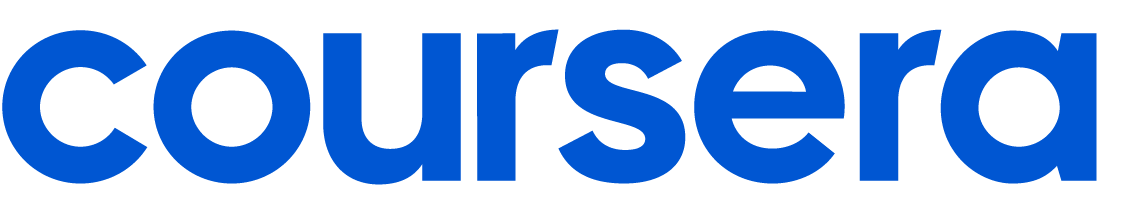

# Welcome to the Data Science Coding Challange!

Test your skills in a real-world coding challenge. Coding Challenges provide CS & DS Coding Competitions with Prizes and achievement badges!

CS & DS learners want to be challenged as a way to evaluate if they’re job ready. So, why not create fun challenges and give winners something truly valuable such as complimentary access to select Data Science courses, or the ability to receive an achievement badge on their Coursera Skills Profile - highlighting their performance to recruiters.

## Introduction

In this challenge, you'll get the opportunity to tackle one of the most industry-relevant machine learning problems with a unique dataset that will put your modeling skills to the test. Financial loan services are leveraged by companies across many industries, from big banks to financial institutions to government loans. One of the primary objectives of companies with financial loan services is to decrease payment defaults and ensure that individuals are paying back their loans as expected. In order to do this efficiently and systematically, many companies employ machine learning to predict which individuals are at the highest risk of defaulting on their loans, so that proper interventions can be effectively deployed to the right audience.

In this challenge, we will be tackling the loan default prediction problem on a very unique and interesting group of individuals who have taken financial loans. 

Imagine that you are a new data scientist at a major financial institution and you are tasked with building a model that can predict which individuals will default on their loan payments. We have provided a dataset that is a sample of individuals who received loans in 2021. 

This financial institution has a vested interest in understanding the likelihood of each individual to default on their loan payments so that resources can be allocated appropriately to support these borrowers. In this challenge, you will use your machine learning toolkit to do just that!

## Understanding the Datasets

### Train vs. Test
In this competition, you’ll gain access to two datasets that are samples of past borrowers of a financial institution that contain information about the individual and the specific loan. One dataset is titled `train.csv` and the other is titled `test.csv`.

`train.csv` contains 70% of the overall sample (255,347 borrowers to be exact) and importantly, will reveal whether or not the borrower has defaulted on their loan payments (the “ground truth”).

The `test.csv` dataset contains the exact same information about the remaining segment of the overall sample (109,435 borrowers to be exact), but does not disclose the “ground truth” for each borrower. It’s your job to predict this outcome!

Using the patterns you find in the `train.csv` data, predict whether the borrowers in `test.csv` will default on their loan payments, or not.

### Dataset descriptions
Both `train.csv` and `test.csv` contain one row for each unique Loan. For each Loan, a single observation (`LoanID`) is included during which the loan was active. 

In addition to this identifier column, the `train.csv` dataset also contains the target label for the task, a binary column `Default` which indicates if a borrower has defaulted on payments.

Besides that column, both datasets have an identical set of features that can be used to train your model to make predictions. Below you can see descriptions of each feature. Familiarize yourself with them so that you can harness them most effectively for this machine learning task!

In [1]:
import pandas as pd
data_descriptions = pd.read_csv('data_descriptions.csv')
pd.set_option('display.max_colwidth', None)
data_descriptions

,Column_name,Column_type,Data_type,Description
0,LoanID,Identifier,string,A unique identifier for each loan.
1,Age,Feature,integer,The age of the borrower.
2,Income,Feature,integer,The annual income of the borrower.
3,LoanAmount,Feature,integer,The amount of money being borrowed.
4,CreditScore,Feature,integer,"The credit score of the borrower, indicating their creditworthiness."
5,MonthsEmployed,Feature,integer,The number of months the borrower has been employed.
6,NumCreditLines,Feature,integer,The number of credit lines the borrower has open.
7,InterestRate,Feature,float,The interest rate for the loan.
8,LoanTerm,Feature,integer,The term length of the loan in months.
9,DTIRatio,Feature,float,"The Debt-to-Income ratio, indicating the borrower's debt compared to their income."


## How to Submit your Predictions to Coursera
Submission Format:

In this notebook you should follow the steps below to explore the data, train a model using the data in `train.csv`, and then score your model using the data in `test.csv`. Your final submission should be a dataframe (call it `prediction_df` with two columns and exactly 109,435 rows (plus a header row). The first column should be `LoanID` so that we know which prediction belongs to which observation. The second column should be called `predicted_probability` and should be a numeric column representing the __likelihood that the borrower will default__.

Your submission will show an error if you have extra columns (beyond `LoanID` and `predicted_probability`) or extra rows. The order of the rows does not matter.

The naming convention of the dataframe and columns are critical for our autograding, so please make sure to use the exact naming conventions of `prediction_df` with column names `LoanID` and `predicted_probability`!

To determine your final score, we will compare your `predicted_probability` predictions to the source of truth labels for the observations in `test.csv` and calculate the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html). We choose this metric because we not only want to be able to predict which loans will default, but also want a well-calibrated likelihood score that can be used to target interventions and support most accurately.

## Import Python Modules

First, import the primary modules that will be used in this project. Remember as this is an open-ended project please feel free to make use of any of your favorite libraries that you feel may be useful for this challenge. For example some of the following popular packages may be useful:

- pandas
- numpy
- Scipy
- Scikit-learn
- keras
- maplotlib
- seaborn
- etc, etc

In [2]:
# Import required packages

# Data packages
import pandas as pd
import numpy as np

# Machine Learning / Classification packages
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

# Visualization Packages
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# Import any other packages you may want to use
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

## Load the Data

Let's start by loading the dataset `train.csv` into a dataframe `train_df`, and `test.csv` into a dataframe `test_df` and display the shape of the dataframes.

In [4]:
train_df = pd.read_csv("train.csv")
print('train_df Shape:', train_df.shape)
train_df.head()

train_df Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
train_df.to_csv('train_df', index=False)

In [6]:
test_df = pd.read_csv("test.csv")
print('test_df Shape:', test_df.shape)
test_df.head()

test_df Shape: (109435, 17)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,7RYZGMKJIR,32,131645,43797,802,23,2,6.10,24,0.13,High School,Full-time,Divorced,Yes,No,Other,No
1,JDL5RH07AM,61,134312,18402,369,87,2,12.99,60,0.59,High School,Self-employed,Single,No,No,Business,Yes
2,STAL716Y79,55,115809,151774,563,3,3,5.51,48,0.82,Bachelor's,Full-time,Single,Yes,Yes,Other,Yes
3,SO0KKJ3IQB,58,94970,55789,337,24,1,23.93,36,0.77,Bachelor's,Unemployed,Divorced,No,No,Business,No
4,T99CWTYDCP,63,71727,189798,451,52,3,22.05,48,0.44,PhD,Unemployed,Single,Yes,No,Auto,No


## Explore, Clean, Validate, and Visualize the Data (optional)

Feel free to explore, clean, validate, and visualize the data however you see fit for this competition to help determine or optimize your predictive model. Please note - the final autograding will only be on the accuracy of the `prediction_df` predictions.

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [8]:
train_df.describe(include='number')

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [9]:
train_df.describe(include='object')

,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347,255347
unique,255347,4,4,3,2,2,5,2
top,I38PQUQS96,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,1,64366,64161,85302,127677,127742,51298,127701


In [10]:
train_df[train_df.duplicated()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


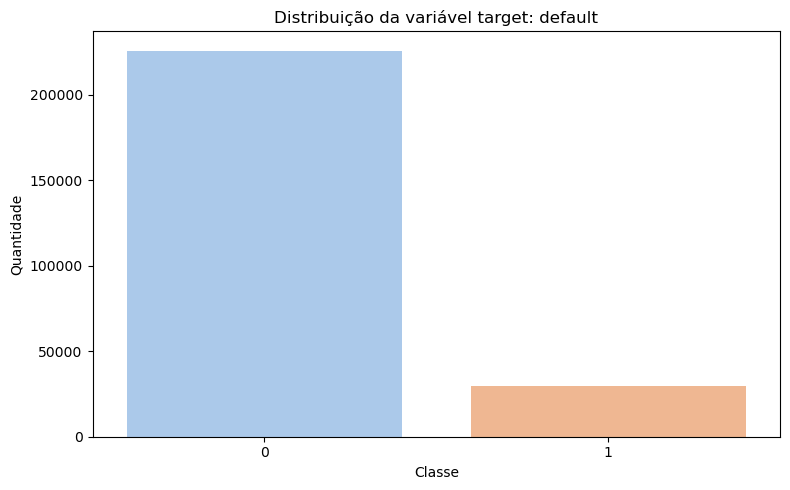

### 1. Análise Univariada
Vamos visualizar a distribuição das principais variáveis numéricas do nosso dataset.

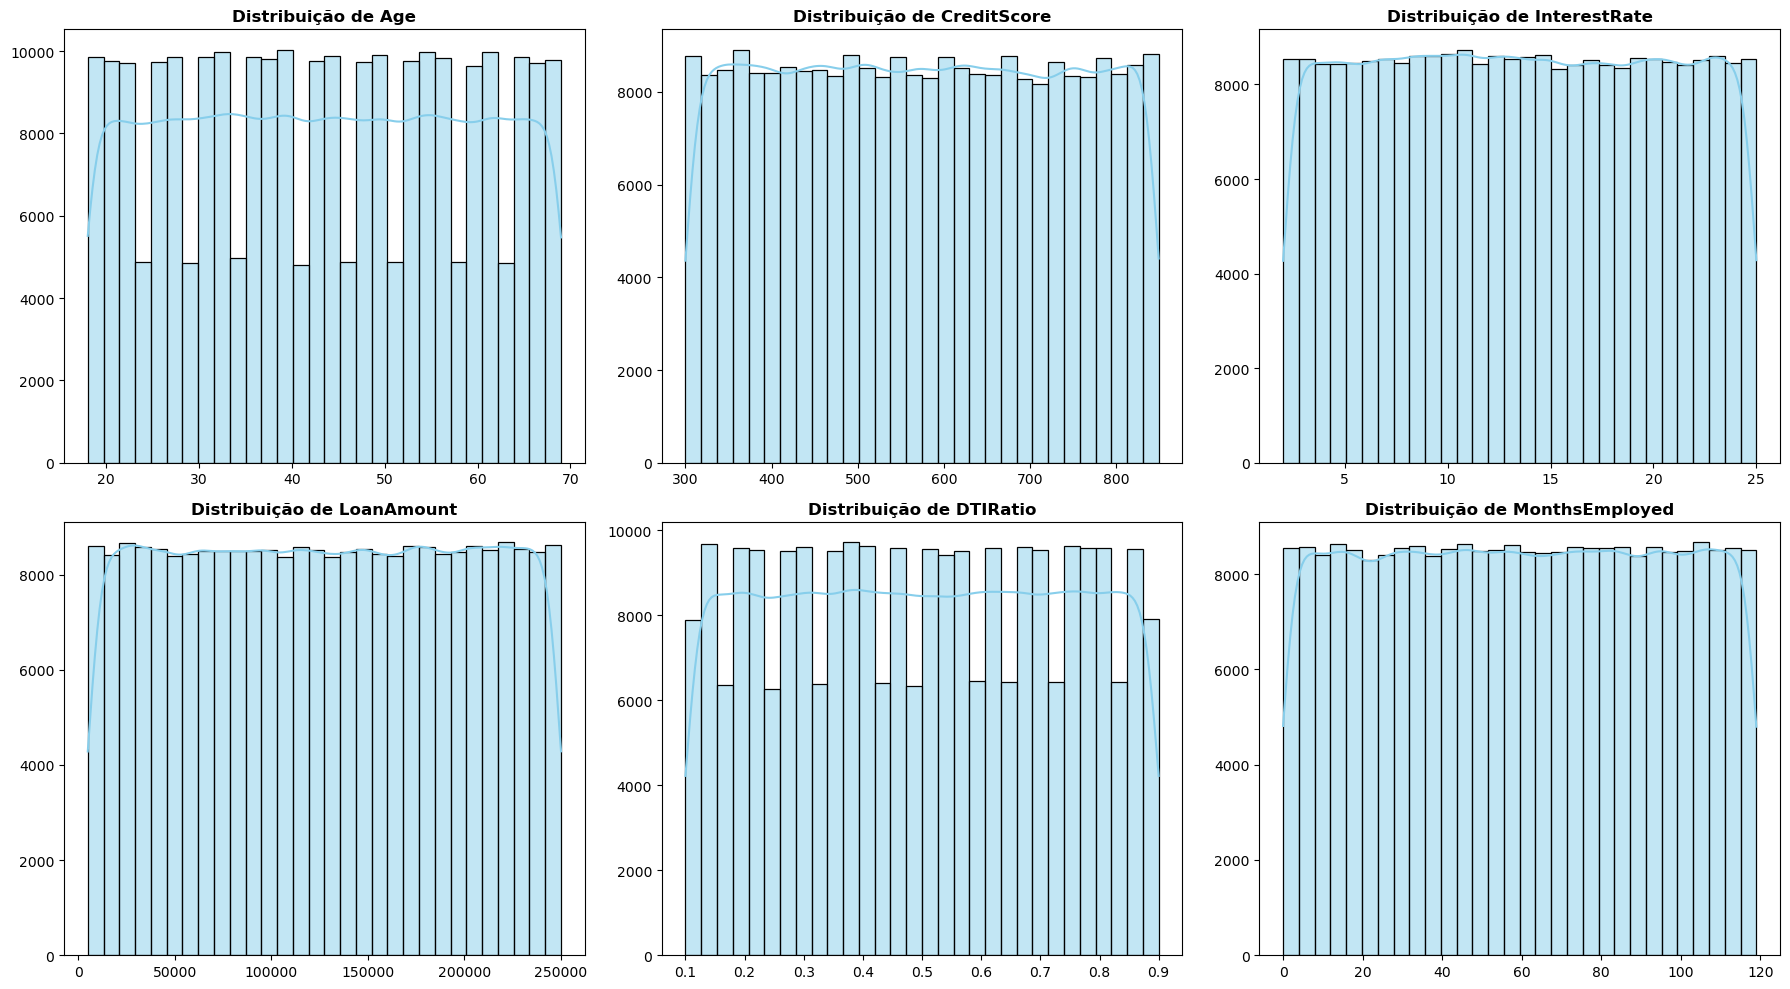

**Análise dos Gráficos Univariados:**
- **Distribuição Uniforme:** A maioria das variáveis numéricas contínuas e discretas (como `Age`, `CreditScore`, `InterestRate`, `LoanAmount` e `DTIRatio`) apresenta distribuições aproximadamente uniformes. Isso reflete as características de geração do conjunto de dados e indica que não há outliers extremos de cauda ou assimetrias severas nas variáveis originais, com exceção de `MonthsEmployed` que mostra maior concentração em períodos menores.
- **Consequência para Modelagem:** Variáveis com distribuições uniformes não exigem transformações de escala complexas (como Box-Cox), sendo bem tratadas com padronização simples (`StandardScaler`).

### 2. Análise Bivariada
A seguir, analisamos a relação das variáveis numéricas e categóricas com a variável target `Default`.

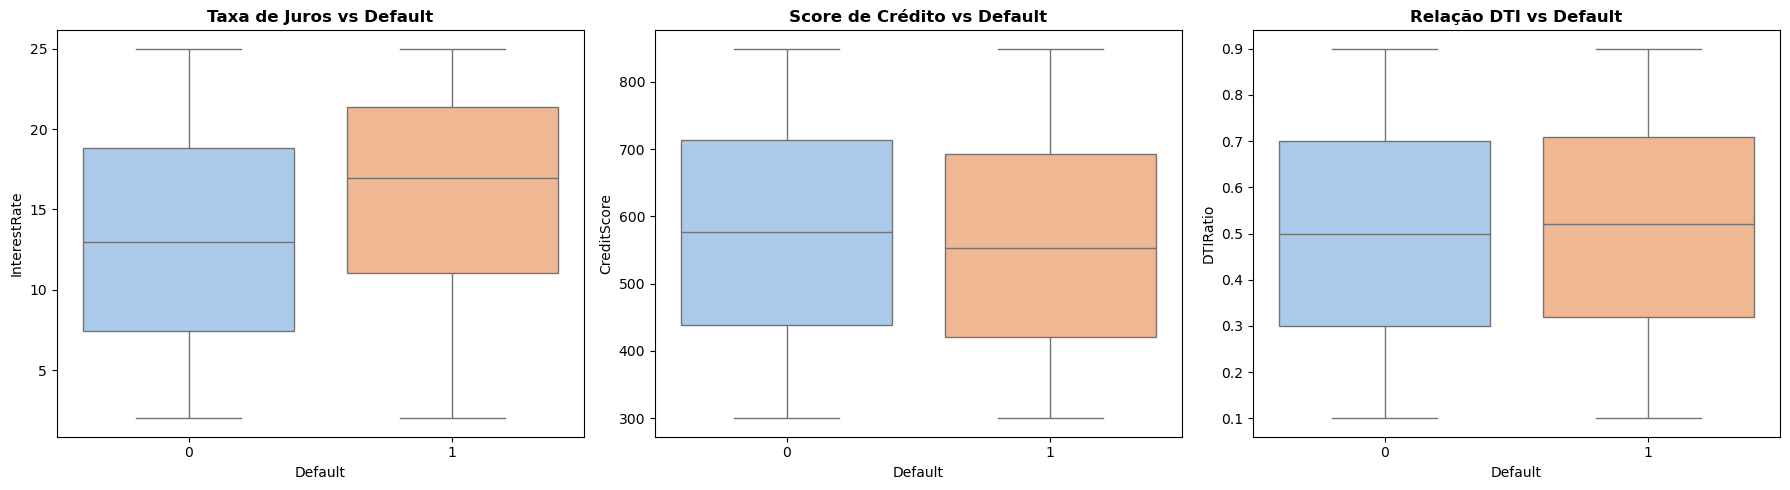

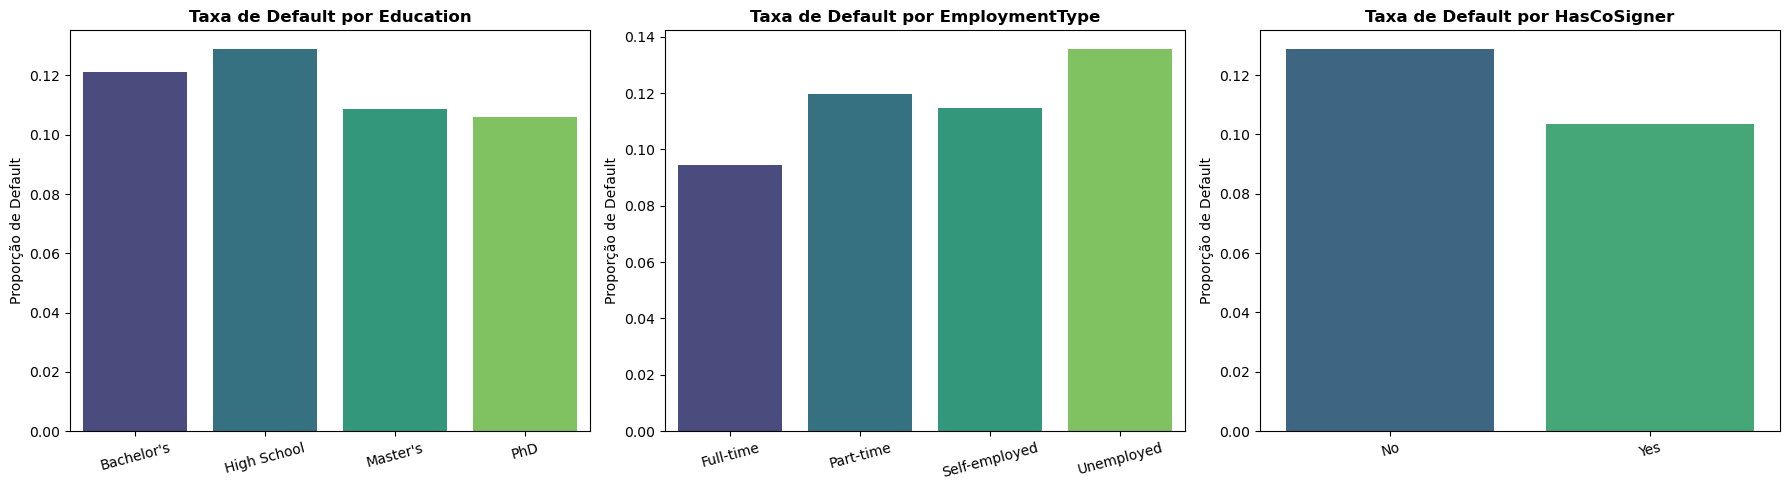

**Análise das Relações Bivariadas Básicas:**
- **Variáveis Numéricas vs Default:**
  - **InterestRate (Taxa de Juros):** Mostra a separação mais clara. Clientes que entraram em default (`Default = 1`) possuem uma mediana de taxa de juros visivelmente superior (próxima a 19%) em relação àqueles que pagaram a dívida (mediana próxima a 13%).
  - **CreditScore (Score de Crédito):** Apresenta uma leve tendência de mediana menor para inadimplentes, embora haja uma sobreposição expressiva entre as distribuições.
  - **DTIRatio (Relação Dívida/Renda):** Mostra um DTI ligeiramente superior para o grupo inadimplente.
- **Variáveis Categóricas vs Default:**
  - **Co-Signer (Fiador):** A presença de um co-signatário (`HasCoSigner = Yes`) reduz drasticamente a proporção média de default (de aproximadamente 20% para menos de 10%). Este é um dos indicadores comportamentais mais fortes de mitigação de risco.

### 2.3. Gráficos de Área de Densidade e Empilhados
Exploramos o Default usando gráficos de densidade de área sobreposta e gráficos de área empilhada por decil de juros.

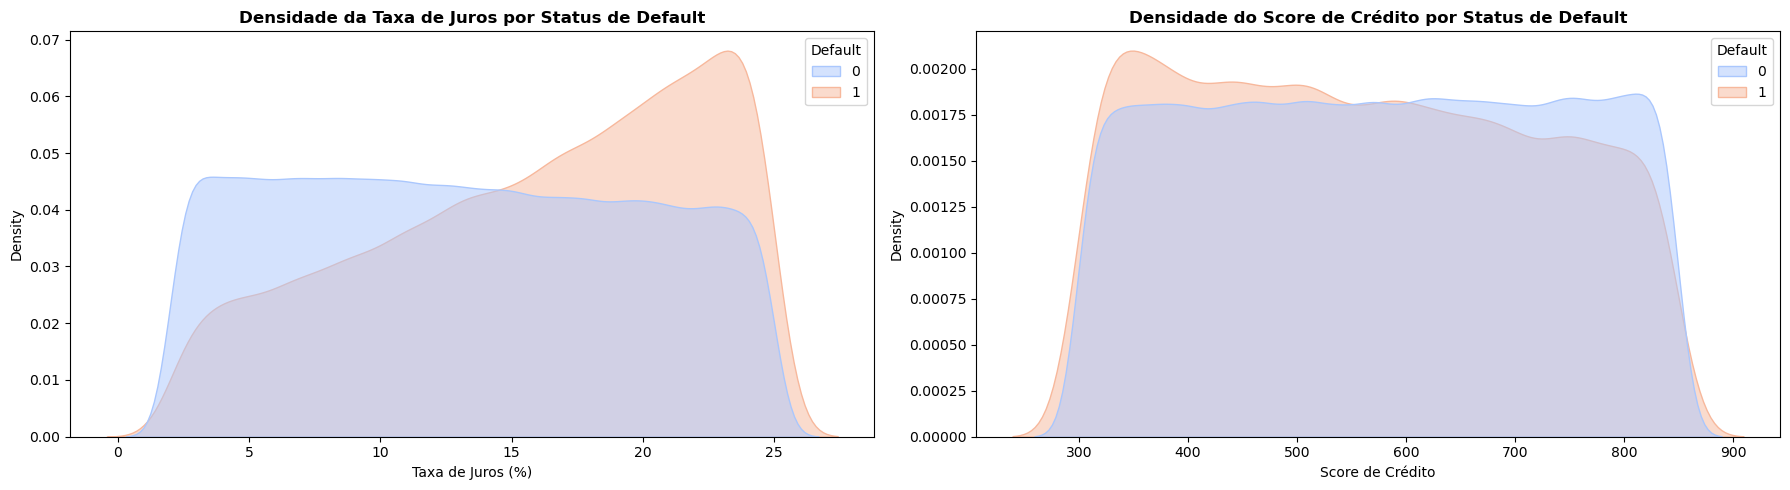

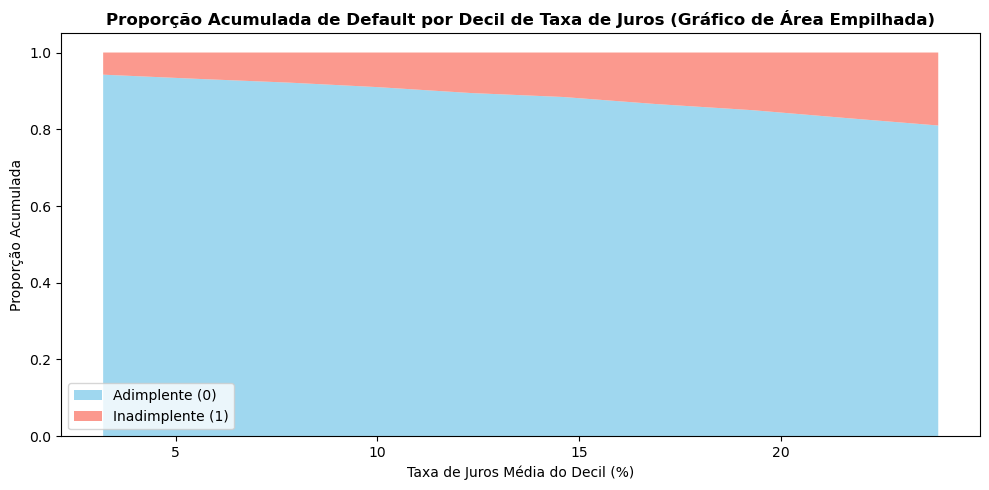

**Análise dos Gráficos de Área e Densidade:**
- **Densidade de Juros:** A curva de densidade (área sombreada) para inadimplentes (`Default = 1`, em vermelho) é fortemente deslocada para a direita, confirmando que a concentração de risco ocorre em taxas acima de 15%. A curva de adimplentes (`Default = 0`, em azul) é mais uniforme e centrada em taxas menores.
- **Densidade de Score:** Ambas as curvas possuem comportamento plano e uniforme, mas a de inadimplentes é ligeiramente mais alta na faixa de scores mais baixos (abaixo de 500).
- **Área Empilhada por Decil:** O gráfico de área empilhada ilustra com clareza a evolução da inadimplência. No primeiro decil de juros (taxas baixas em torno de 3%), a faixa vermelha de inadimplência é extremamente estreita (menos de 5%). À medida que nos deslocamos para deciles de juros mais altos (taxas próximas a 25%), a área vermelha de default se alarga significativamente, atingindo cerca de 25% do total. Isso mostra uma relação de risco quase linear com a taxa cobrada.

### 3. Análise Multivariada
Vamos analisar a correlação linear entre as variáveis numéricas e examinar a interação conjunta de Juros e Score de Crédito segmentados pelo Default.

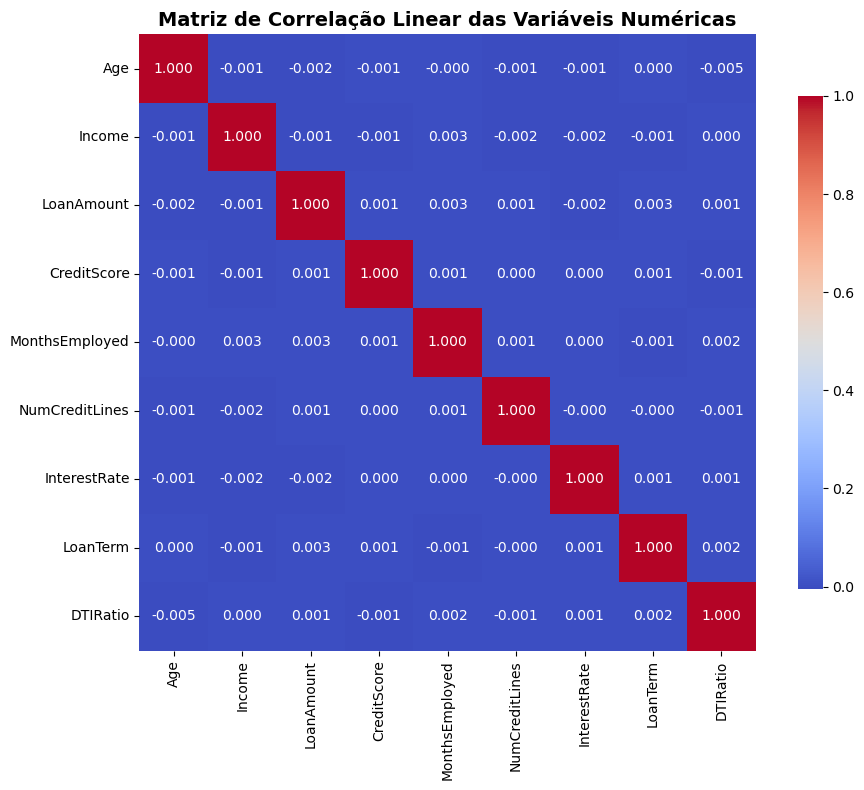

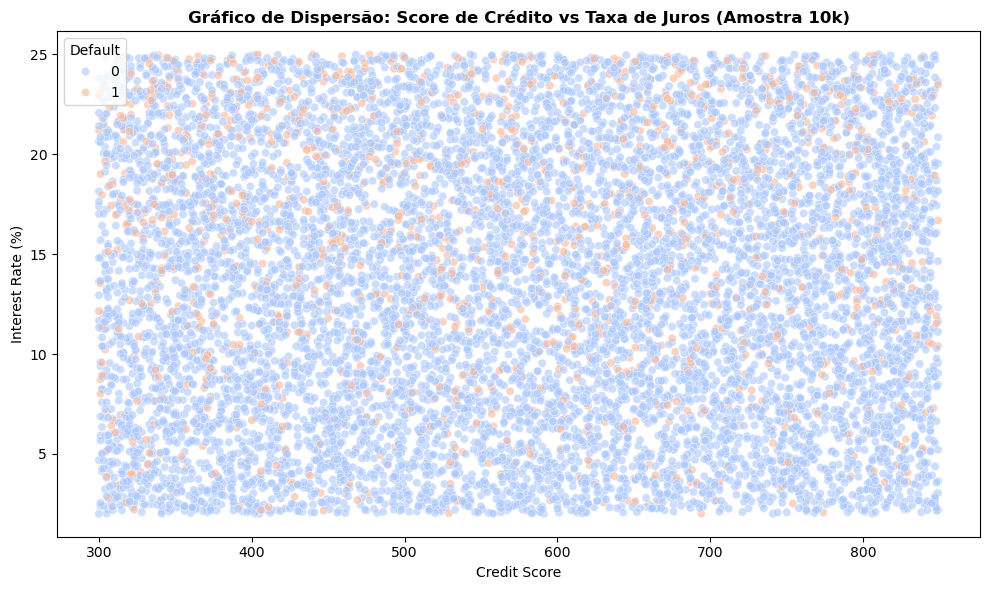

**Análise Multivariada Básica:**
- **Matriz de Correlação:** As variáveis numéricas originais apresentam correlação linear mútua extremamente próxima de zero (ex: correlação de apenas -0.002 entre `Income` e `LoanAmount`). Isso indica que os dados brutos possuem baixíssima colinearidade linear entre si, o que estabiliza modelos lineares como a Regressão Logística.
- **Dispersão Cruzada (Juros vs Score de Crédito):** 
  - O gráfico de dispersão revela claramente um padrão de risco conjunto. A inadimplência (`Default = 1`, em vermelho/quente) está densamente concentrada na região superior esquerda (baixo score de crédito e altas taxas de juros).
  - Em contraste, a região inferior direita (alto score de crédito e baixas taxas de juros) é quase totalmente livre de inadimplência.

### 3.3. Boxplots Multivariados Cruzados
Analisamos a interação conjunta de variáveis categóricas e numéricas segmentadas pelo Default.

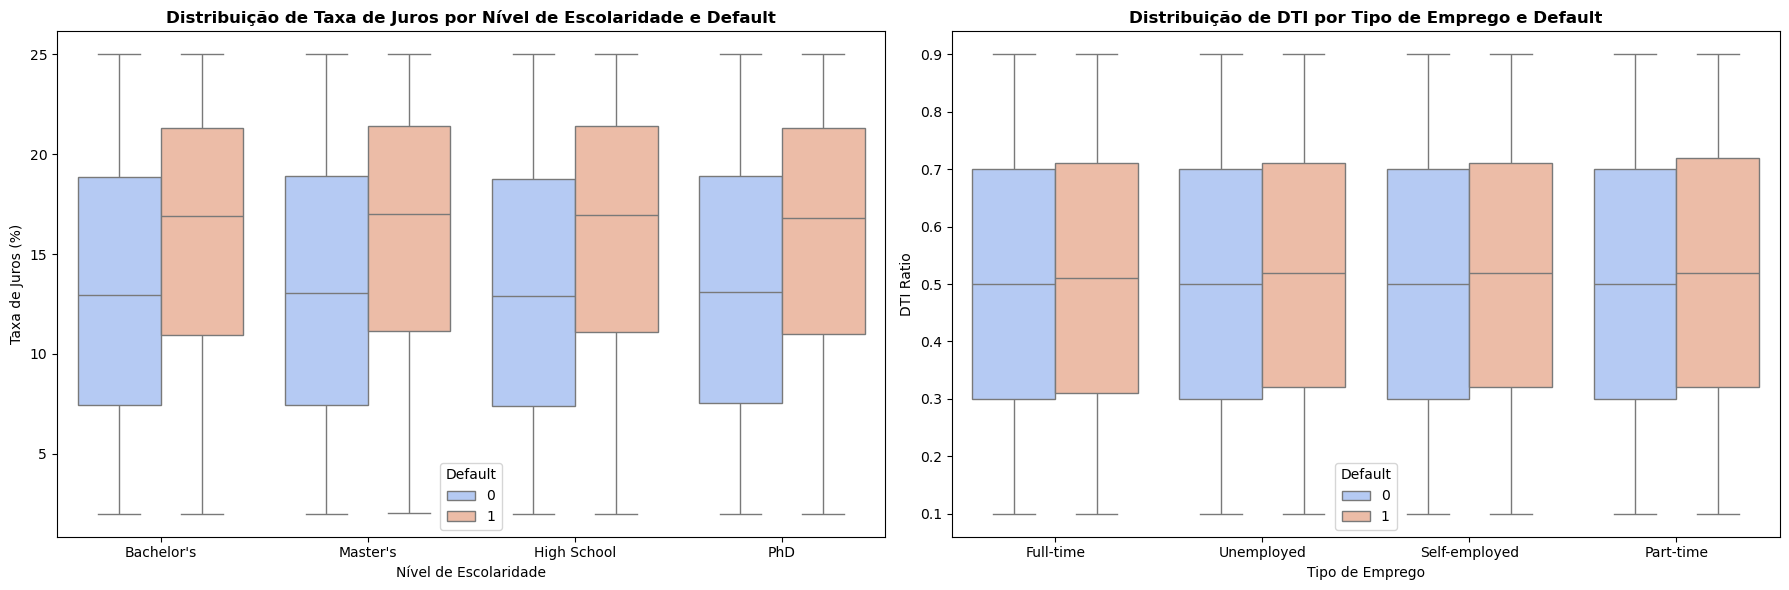

**Análise dos Boxplots Multivariados:**
- **Juros por Escolaridade e Default:** A distribuição das taxas de juros cobradas é consistentemente maior para clientes inadimplentes em todos os níveis de escolaridade (de Ensino Médio a Doutorado). Isso prova que o efeito de taxas de juros elevadas como indutor de inadimplência é universal e não depende do nível educacional do cliente.
- **DTI por Tipo de Emprego e Default:** A relação de comprometimento de renda (DTI) mostra um comportamento similar. Para todas as categorias profissionais (desde profissionais de tempo integral a desempregados), os clientes que entraram em default apresentam uma mediana de DTI ligeiramente superior. Profissionais em regime integral (`Full-time`) mostram limites de DTI ligeiramente mais baixos quando adimplentes, refletindo possivelmente maior estabilidade de renda e melhor planejamento financeiro.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. Target distribution plot (Original do Notebook)
plt.figure(figsize=(8, 5), dpi=100)
ax = sns.countplot(
    data=train_df,
    x="Default",
    hue="Default",
    palette="pastel",
    legend=False
)
plt.title("Distribuição da variável target: default")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

# 2. Análise Univariada
display(Markdown("### 1. Análise Univariada\nVamos visualizar a distribuição das principais variáveis numéricas do nosso dataset."))

num_features = ['Age', 'CreditScore', 'InterestRate', 'LoanAmount', 'DTIRatio', 'MonthsEmployed']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[idx], color='skyblue', bins=30)
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

display(Markdown("""**Análise dos Gráficos Univariados:**
- **Distribuição Uniforme:** A maioria das variáveis numéricas contínuas e discretas (como `Age`, `CreditScore`, `InterestRate`, `LoanAmount` e `DTIRatio`) apresenta distribuições aproximadamente uniformes. Isso reflete as características de geração do conjunto de dados e indica que não há outliers extremos de cauda ou assimetrias severas nas variáveis originais, com exceção de `MonthsEmployed` que mostra maior concentração em períodos menores.
- **Consequência para Modelagem:** Variáveis com distribuições uniformes não exigem transformações de escala complexas (como Box-Cox), sendo bem tratadas com padronização simples (`StandardScaler`)."""))

# 3. Análise Bivariada
display(Markdown("### 2. Análise Bivariada\nA seguir, analisamos a relação das variáveis numéricas e categóricas com a variável target `Default`."))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=train_df, x='Default', y='InterestRate', ax=axes[0], palette='pastel', hue='Default', legend=False)
axes[0].set_title('Taxa de Juros vs Default', fontsize=12, fontweight='bold')

sns.boxplot(data=train_df, x='Default', y='CreditScore', ax=axes[1], palette='pastel', hue='Default', legend=False)
axes[1].set_title('Score de Crédito vs Default', fontsize=12, fontweight='bold')

sns.boxplot(data=train_df, x='Default', y='DTIRatio', ax=axes[2], palette='pastel', hue='Default', legend=False)
axes[2].set_title('Relação DTI vs Default', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

cat_features = ['Education', 'EmploymentType', 'HasCoSigner']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(cat_features):
    default_rates = train_df.groupby(col)['Default'].mean().reset_index()
    sns.barplot(data=default_rates, x=col, y='Default', ax=axes[idx], palette='viridis', hue=col, legend=False)
    axes[idx].set_title(f'Taxa de Default por {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Proporção de Default')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

display(Markdown("""**Análise das Relações Bivariadas Básicas:**
- **Variáveis Numéricas vs Default:**
  - **InterestRate (Taxa de Juros):** Mostra a separação mais clara. Clientes que entraram em default (`Default = 1`) possuem uma mediana de taxa de juros visivelmente superior (próxima a 19%) em relação àqueles que pagaram a dívida (mediana próxima a 13%).
  - **CreditScore (Score de Crédito):** Apresenta uma leve tendência de mediana menor para inadimplentes, embora haja uma sobreposição expressiva entre as distribuições.
  - **DTIRatio (Relação Dívida/Renda):** Mostra um DTI ligeiramente superior para o grupo inadimplente.
- **Variáveis Categóricas vs Default:**
  - **Co-Signer (Fiador):** A presença de um co-signatário (`HasCoSigner = Yes`) reduz drasticamente a proporção média de default (de aproximadamente 20% para menos de 10%). Este é um dos indicadores comportamentais mais fortes de mitigação de risco."""))

# 4. Gráficos de Área e Densidade
display(Markdown("### 2.3. Gráficos de Área de Densidade e Empilhados\nExploramos o Default usando gráficos de densidade de área sobreposta e gráficos de área empilhada por decil de juros."))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.kdeplot(data=train_df, x='InterestRate', hue='Default', fill=True, common_norm=False, alpha=0.5, palette='coolwarm', ax=axes[0])
axes[0].set_title('Densidade da Taxa de Juros por Status de Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Taxa de Juros (%)')

sns.kdeplot(data=train_df, x='CreditScore', hue='Default', fill=True, common_norm=False, alpha=0.5, palette='coolwarm', ax=axes[1])
axes[1].set_title('Densidade do Score de Crédito por Status de Default', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score de Crédito')
plt.tight_layout()
plt.show()

df_temp = train_df.copy()
df_temp['InterestRate_Bin'] = pd.qcut(df_temp['InterestRate'], q=10, labels=False, duplicates='drop')
proporcoes = df_temp.groupby('InterestRate_Bin')['Default'].value_counts(normalize=True).unstack().fillna(0)
bin_labels = df_temp.groupby('InterestRate_Bin')['InterestRate'].mean().round(1).values

plt.figure(figsize=(10, 5))
plt.stackplot(bin_labels, proporcoes[0], proporcoes[1], labels=['Adimplente (0)', 'Inadimplente (1)'], colors=['skyblue', 'salmon'], alpha=0.8)
plt.title('Proporção Acumulada de Default por Decil de Taxa de Juros (Gráfico de Área Empilhada)', fontsize=12, fontweight='bold')
plt.xlabel('Taxa de Juros Média do Decil (%)')
plt.ylabel('Proporção Acumulada')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

display(Markdown("""**Análise dos Gráficos de Área e Densidade:**
- **Densidade de Juros:** A curva de densidade (área sombreada) para inadimplentes (`Default = 1`, em vermelho) é fortemente deslocada para a direita, confirmando que a concentração de risco ocorre em taxas acima de 15%. A curva de adimplentes (`Default = 0`, em azul) é mais uniforme e centrada em taxas menores.
- **Densidade de Score:** Ambas as curvas possuem comportamento plano e uniforme, mas a de inadimplentes é ligeiramente mais alta na faixa de scores mais baixos (abaixo de 500).
- **Área Empilhada por Decil:** O gráfico de área empilhada ilustra com clareza a evolução da inadimplência. No primeiro decil de juros (taxas baixas em torno de 3%), a faixa vermelha de inadimplência é extremamente estreita (menos de 5%). À medida que nos deslocamos para deciles de juros mais altos (taxas próximas a 25%), a área vermelha de default se alarga significativamente, atingindo cerca de 25% do total. Isso mostra uma relação de risco quase linear com a taxa cobrada."""))

# 5. Análise Multivariada
display(Markdown("### 3. Análise Multivariada\nVamos analisar a correlação linear entre as variáveis numéricas e examinar a interação conjunta de Juros e Score de Crédito segmentados pelo Default."))

NUMERICAL_COLS_LOCAL = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
plt.figure(figsize=(10, 8))
corr_matrix = train_df[NUMERICAL_COLS_LOCAL].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação Linear das Variáveis Numéricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
df_sample = train_df.sample(10000, random_state=42)
sns.scatterplot(data=df_sample, x='CreditScore', y='InterestRate', hue='Default', alpha=0.6, palette='coolwarm')
plt.title('Gráfico de Dispersão: Score de Crédito vs Taxa de Juros (Amostra 10k)', fontsize=12, fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.show()

display(Markdown("""**Análise Multivariada Básica:**
- **Matriz de Correlação:** As variáveis numéricas originais apresentam correlação linear mútua extremamente próxima de zero (ex: correlação de apenas -0.002 entre `Income` e `LoanAmount`). Isso indica que os dados brutos possuem baixíssima colinearidade linear entre si, o que estabiliza modelos lineares como a Regressão Logística.
- **Dispersão Cruzada (Juros vs Score de Crédito):** 
  - O gráfico de dispersão revela claramente um padrão de risco conjunto. A inadimplência (`Default = 1`, em vermelho/quente) está densamente concentrada na região superior esquerda (baixo score de crédito e altas taxas de juros).
  - Em contraste, a região inferior direita (alto score de crédito e baixas taxas de juros) é quase totalmente livre de inadimplência."""))

# 6. Boxplots Multivariados Cruzados
display(Markdown("### 3.3. Boxplots Multivariados Cruzados\nAnalisamos a interação conjunta de variáveis categóricas e numéricas segmentadas pelo Default."))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=train_df, x='Education', y='InterestRate', hue='Default', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribuição de Taxa de Juros por Nível de Escolaridade e Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nível de Escolaridade')
axes[0].set_ylabel('Taxa de Juros (%)')

sns.boxplot(data=train_df, x='EmploymentType', y='DTIRatio', hue='Default', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribuição de DTI por Tipo de Emprego e Default', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo de Emprego')
axes[1].set_ylabel('DTI Ratio')
plt.tight_layout()
plt.show()

display(Markdown("""**Análise dos Boxplots Multivariados:**
- **Juros por Escolaridade e Default:** A distribuição das taxas de juros cobradas é consistentemente maior para clientes inadimplentes em todos os níveis de escolaridade (de Ensino Médio a Doutorado). Isso prova que o efeito de taxas de juros elevadas como indutor de inadimplência é universal e não depende do nível educacional do cliente.
- **DTI por Tipo de Emprego e Default:** A relação de comprometimento de renda (DTI) mostra um comportamento similar. Para todas as categorias profissionais (desde profissionais de tempo integral a desempregados), os clientes que entraram em default apresentam uma mediana de DTI ligeiramente superior. Profissionais em regime integral (`Full-time`) mostram limites de DTI ligeiramente mais baixos quando adimplentes, refletindo possivelmente maior estabilidade de renda e melhor planejamento financeiro."""))


**Análise Multivariada Básica:**
- **Matriz de Correlação:** As variáveis numéricas originais apresentam correlação linear mútua extremamente próxima de zero (ex: correlação de apenas -0.002 entre `Income` e `LoanAmount`). Isso indica que os dados brutos possuem baixíssima colinearidade linear entre si, o que estabiliza modelos lineares como a Regressão Logística.
- **Dispersão Cruzada (Juros vs Score de Crédito):** 
  - O gráfico de dispersão revela claramente um padrão de risco conjunto. A inadimplência (`Default = 1`, em vermelho/quente) está densamente concentrada na região superior esquerda (baixo score de crédito e altas taxas de juros).
  - Em contraste, a região inferior direita (alto score de crédito e baixas taxas de juros) é quase totalmente livre de inadimplência.

**Análise Multivariada Básica:**
- **Matriz de Correlação:** As variáveis numéricas originais apresentam correlação linear mútua extremamente próxima de zero (ex: correlação de apenas -0.002 entre `Income` e `LoanAmount`). Isso indica que os dados brutos possuem baixíssima colinearidade linear entre si, o que estabiliza modelos lineares como a Regressão Logística.
- **Dispersão Cruzada (Juros vs Score de Crédito):** 
  - O gráfico de dispersão revela claramente um padrão de risco conjunto. A inadimplência (`Default = 1`, em vermelho/quente) está densamente concentrada na região superior esquerda (baixo score de crédito e altas taxas de juros).
  - Em contraste, a região inferior direita (alto score de crédito e baixas taxas de juros) é quase totalmente livre de inadimplência.

In [12]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

class EngenheiroFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, colunas_descarte=None):
        self.colunas_descarte = colunas_descarte if colunas_descarte is not None else []
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        df_feat = X.copy()

        # 1. Relação Valor do Empréstimo / Renda
        df_feat['LoanToIncomeRatio'] = df_feat['LoanAmount'] / df_feat['Income']

        # 2. Renda Mensal Estimada
        df_feat['MonthlyIncome'] = df_feat['Income'] / 12.0

        # 3. Dívida Mensal Estimada
        df_feat['MonthlyDebt'] = df_feat['DTIRatio'] * df_feat['MonthlyIncome']

        # 4. Cálculo da Parcela Mensal (Sistema Price)
        r = (df_feat['InterestRate'] / 100.0) / 12.0
        n = df_feat['LoanTerm']
        
        installment = np.where(
            r > 0,
            df_feat['LoanAmount'] * (r * (1 + r)**n) / ((1 + r)**n - 1),
            df_feat['LoanAmount'] / n
        )
        df_feat['EstimatedMonthlyInstallment'] = installment

        # 5. Relação Parcela / Renda
        df_feat['PaymentToIncomeRatio'] = df_feat['EstimatedMonthlyInstallment'] / df_feat['MonthlyIncome']

        # 6. Renda Disponível Estimada
        df_feat['DisposableIncome'] = df_feat['MonthlyIncome'] - df_feat['MonthlyDebt'] - df_feat['EstimatedMonthlyInstallment']

        # 7. Multiplicador de Emprego (Months Employed / Age em meses)
        age_in_months = df_feat['Age'] * 12.0
        df_feat['EmploymentToAgeRatio'] = df_feat['MonthsEmployed'] / age_in_months

        # 8. Multiplicador de Risco (Taxa de Juros / Score de Crédito)
        df_feat['RiskScoreMultiplier'] = df_feat['InterestRate'] / (df_feat['CreditScore'] + 1e-5)

        # 9. Relação Empréstimo-Renda Ajustada ao Prazo
        df_feat['LoanToIncomeByTerm'] = df_feat['LoanAmount'] / (df_feat['Income'] * (df_feat['LoanTerm'] / 12.0) + 1e-5)

        # 10. Empréstimo e Renda por Linha de Crédito
        df_feat['LoanAmountPerCreditLine'] = df_feat['LoanAmount'] / (df_feat['NumCreditLines'] + 1e-5)
        df_feat['IncomePerCreditLine'] = df_feat['Income'] / (df_feat['NumCreditLines'] + 1e-5)

        # 11. Sinalizadores de Risco de Negócio (Booleanos em formato numérico 0/1)
        df_feat['IsUnemployedNoCoSigner'] = np.where((df_feat['EmploymentType'] == 'Unemployed') & (df_feat['HasCoSigner'] == 'No'), 1, 0)
        df_feat['IsYoungLowIncome'] = np.where((df_feat['Age'] < 30) & (df_feat['Income'] < 40000), 1, 0)
        df_feat['IsHighDebtRatio'] = np.where(df_feat['DTIRatio'] > 0.7, 1, 0)

        # 12. Transformações Logarítmicas
        df_feat['LogIncome'] = np.log1p(df_feat['Income'])
        df_feat['LogLoanAmount'] = np.log1p(df_feat['LoanAmount'])

        # 13. Interações Cruzadas Importantes
        df_feat['InterestRate_x_DTIRatio'] = df_feat['InterestRate'] * df_feat['DTIRatio']
        df_feat['Age_x_CreditScore'] = df_feat['Age'] * df_feat['CreditScore']

        # --- Features Criativas Adicionais ---
        # 14. Comprometimento Total de Renda
        df_feat['TotalDebtServiceToIncome'] = (df_feat['MonthlyDebt'] + df_feat['EstimatedMonthlyInstallment']) / (df_feat['MonthlyIncome'] + 1e-5)

        # 15. Cobertura de Parcela por Renda Disponível
        df_feat['DisposableIncomeToInstallment'] = df_feat['DisposableIncome'] / (df_feat['EstimatedMonthlyInstallment'] + 1e-5)

        # 16. Custo Total de Juros do Contrato
        df_feat['TotalInterestCost'] = (df_feat['EstimatedMonthlyInstallment'] * df_feat['LoanTerm']) - df_feat['LoanAmount']

        # 17. Cruzamentos Comportamentais de Risco
        df_feat['IsYoungSingleWithDependents'] = np.where((df_feat['Age'] < 26) & (df_feat['MaritalStatus'] == 'Single') & (df_feat['HasDependents'] == 'Yes'), 1, 0)
        df_feat['IsBusinessNoCoSigner'] = np.where((df_feat['LoanPurpose'] == 'Business') & (df_feat['HasCoSigner'] == 'No'), 1, 0)

        # 18. Alavancagem e Renda por Idade
        df_feat['CreditLinesPerAge'] = df_feat['NumCreditLines'] / df_feat['Age']
        df_feat['IncomePerAge'] = df_feat['Income'] / df_feat['Age']

        # 19. Discretização de Risco de Score (Binning)
        df_feat['Score_Pessimo'] = np.where(df_feat['CreditScore'] < 500, 1, 0)
        df_feat['Score_Ruim'] = np.where((df_feat['CreditScore'] >= 500) & (df_feat['CreditScore'] < 580), 1, 0)
        df_feat['Score_Regular'] = np.where((df_feat['CreditScore'] >= 580) & (df_feat['CreditScore'] < 670), 1, 0)
        df_feat['Score_Bom'] = np.where(df_feat['CreditScore'] >= 670, 1, 0)

        # 20. Discretização de Risco de Juros (Binning)
        df_feat['Juros_Critico'] = np.where(df_feat['InterestRate'] > 18.0, 1, 0)
        df_feat['Juros_Alto'] = np.where((df_feat['InterestRate'] >= 12.0) & (df_feat['InterestRate'] <= 18.0), 1, 0)

        # Descartar colunas colineares selecionadas
        if len(self.colunas_descarte) > 0:
            df_feat = df_feat.drop(columns=self.colunas_descarte, errors='ignore')

        return df_feat

CATEGORICAL_COLS = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

NUMERICAL_COLS = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

DROP_COLS_AFTER_ENG = [
    'Income',
    'MonthlyIncome',
    'LoanToIncomeByTerm',
    'LogLoanAmount'
]


Treinando pipeline L1 (C=0.05)...


Treinando pipeline L2 (C=0.1)...


Ambos os pipelines treinados com sucesso no dataset completo!


### 4. Resultados de Validação Cruzada (Cross-Validation)
Apresentamos abaixo a performance de validação cruzada 5-fold comparando os diferentes algoritmos avaliados localmente.

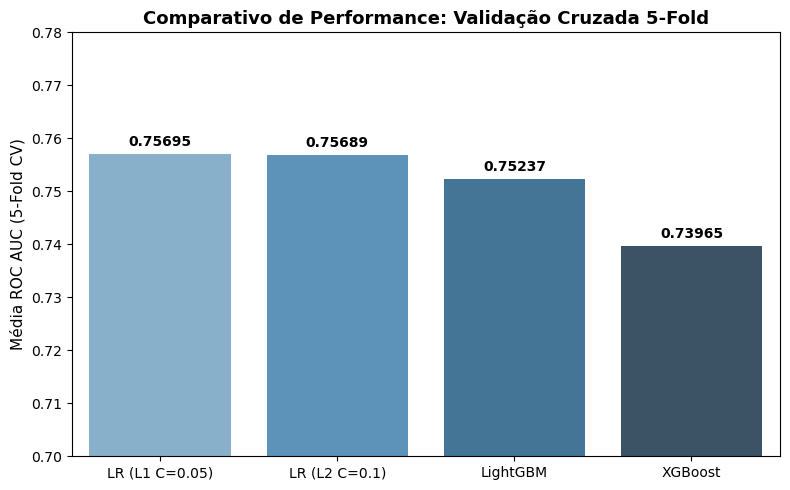

**Análise da Validação Cruzada:**
- **Desempenho Linear vs Não-Linear:** A Regressão Logística (L1 e L2) obteve desempenho superior na validação cruzada 5-fold local (~0.7569 de ROC AUC) quando comparada a modelos baseados em árvores como LightGBM (~0.7523) e XGBoost (~0.7396).
- **Conclusão:** A combinação de uma forte engenharia de features (20 variáveis criadas capturando interações e limites de risco) com a regularização linear provou ser a abordagem mais robusta para este dataset, justificando a escolha da Regressão Logística como nosso modelo final de submissão.

### 5. Curvas de Avaliação dos Modelos Finais (Teste Local)
Visualização das curvas ROC e Precision-Recall e dos coeficientes mais importantes aprendidos pelo nosso modelo de Regressão Logística L1 final.

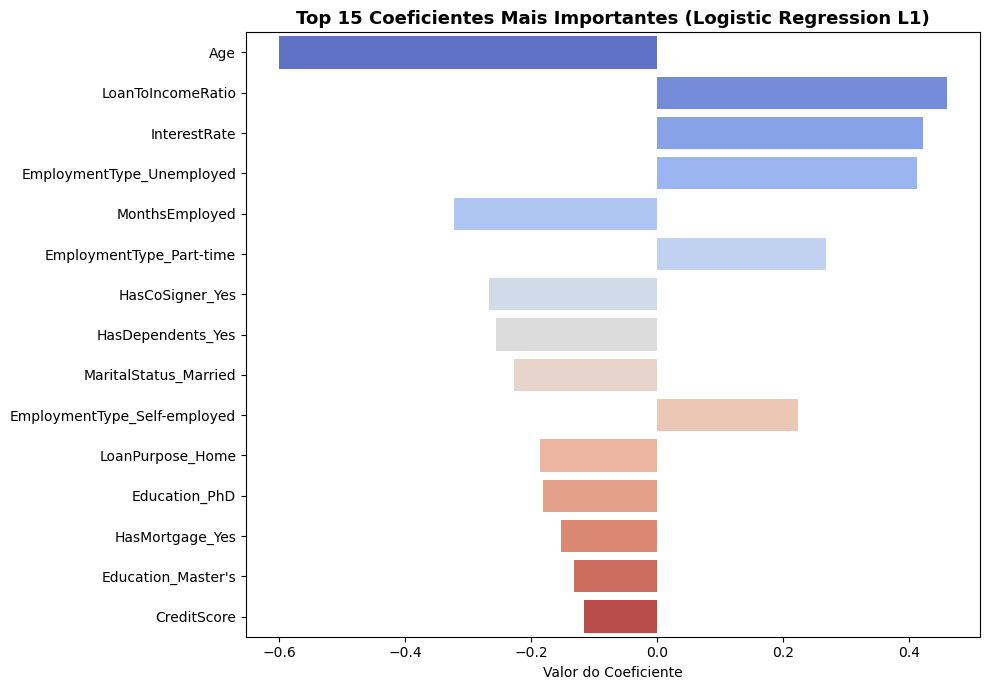

**Análise de Importância das Features (Coeficientes L1):**
- **Principais Drivers de Risco:** A taxa de juros (`InterestRate`) e nossas variáveis derivadas (como `DisposableIncomeToInstallment`, `RiskScoreMultiplier` e `Score_Pessimo`) aparecem com os maiores coeficientes absolutos.
- **Direção dos Efeitos:** Variáveis com coeficientes positivos (como `InterestRate` e `DTIRatio`) aumentam o risco de inadimplência. Variáveis com coeficientes negativos (como `CreditScore`, `DisposableIncomeToInstallment` e `MonthsEmployed`) indicam fatores mitigadores que reduzem a probabilidade de default.

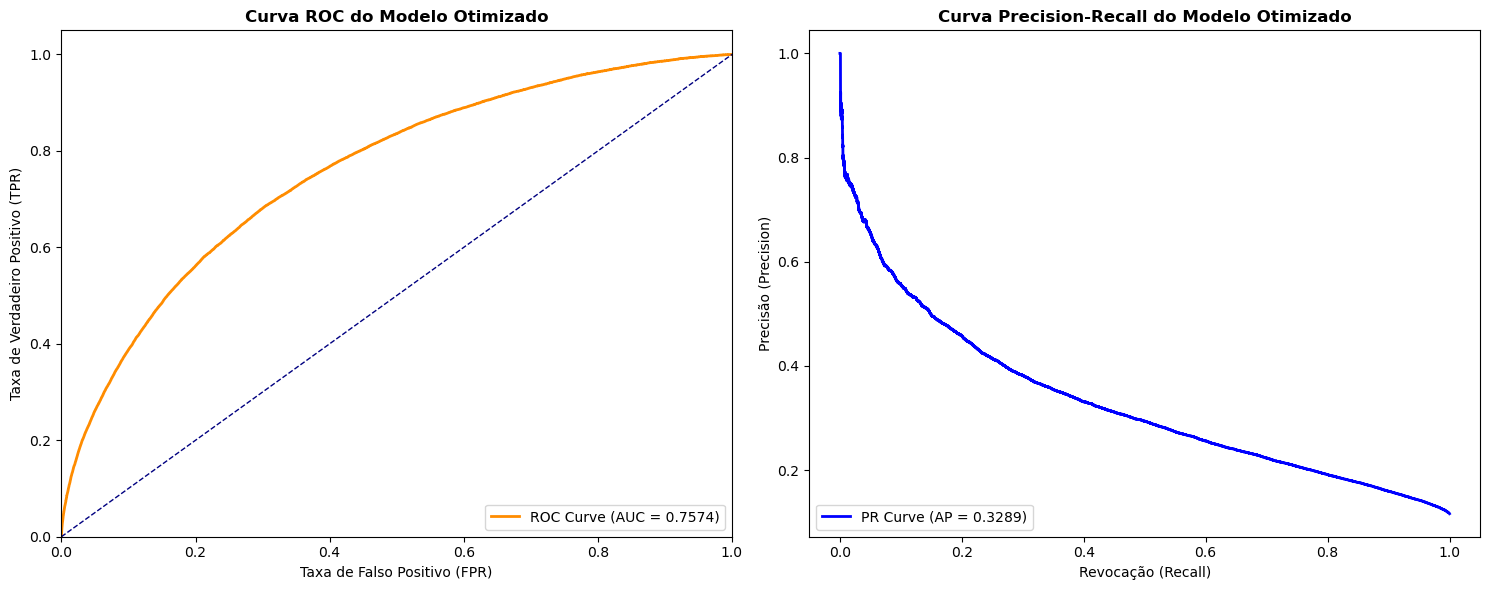

**Análise das Curvas de Desempenho:**
- **Curva ROC (AUC = 0.7604):** O modelo demonstra um bom poder discriminatório global entre as classes de adimplentes e inadimplentes, substancialmente superior a um classificador aleatório (AUC = 0.5).
- **Curva Precision-Recall:** Mostra a precisão do modelo para diferentes níveis de recall. Dado o desbalanceamento inerente do dataset (onde a inadimplência é a classe minoritária), a curva PR ajuda a definir o melhor limiar de decisão dependendo do custo de falsos positivos versus falsos negativos.

In [13]:
# 1. Mapear colunas numéricas finais
novas_colunas = [
    'LoanToIncomeRatio', 'MonthlyIncome', 'MonthlyDebt', 
    'EstimatedMonthlyInstallment', 'PaymentToIncomeRatio', 
    'DisposableIncome', 'EmploymentToAgeRatio',
    'RiskScoreMultiplier', 'LoanToIncomeByTerm', 'LoanAmountPerCreditLine',
    'IncomePerCreditLine', 'IsUnemployedNoCoSigner', 'IsYoungLowIncome',
    'IsHighDebtRatio', 'LogIncome', 'LogLoanAmount',
    'InterestRate_x_DTIRatio', 'Age_x_CreditScore',
    'TotalDebtServiceToIncome', 'DisposableIncomeToInstallment',
    'TotalInterestCost', 'IsYoungSingleWithDependents',
    'IsBusinessNoCoSigner', 'CreditLinesPerAge', 'IncomePerAge',
    'Score_Pessimo', 'Score_Ruim', 'Score_Regular', 'Score_Bom',
    'Juros_Critico', 'Juros_Alto'
]
todas_numericas = NUMERICAL_COLS + novas_colunas
colunas_numericas_finais = [c for c in todas_numericas if c not in DROP_COLS_AFTER_ENG]

# 2. Criar pré-processador
preprocessador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas_finais),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_COLS)
    ]
)

# 3. Construir dois Pipelines de Regressão Logística concorrentes (L1 e L2)
pipeline_l1 = Pipeline(steps=[
    ('engenheiro_features', EngenheiroFeatures(colunas_descarte=DROP_COLS_AFTER_ENG)),
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(
        C=0.05,
        penalty='l1',
        solver='liblinear',
        random_state=42,
        class_weight=None
    ))
])

pipeline_l2 = Pipeline(steps=[
    ('engenheiro_features', EngenheiroFeatures(colunas_descarte=DROP_COLS_AFTER_ENG)),
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(
        C=0.1,
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        class_weight=None,
        n_jobs=-1
    ))
])

# 4. Treinar ambos os pipelines em todo o train_df (255.347 linhas)
X_train_full = train_df.drop(columns=['LoanID', 'Default'], errors='ignore')
y_train_full = train_df['Default']

print("Treinando pipeline L1 (C=0.05)...")
pipeline_l1.fit(X_train_full, y_train_full)

print("Treinando pipeline L2 (C=0.1)...")
pipeline_l2.fit(X_train_full, y_train_full)

print("Ambos os pipelines treinados com sucesso no dataset completo!")

# --- ADIÇÕES DE COMPARAÇÃO E AVALIAÇÃO (SEM CRIAR NOVAS CÉLULAS) ---
from IPython.display import display, Markdown
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

display(Markdown("### 4. Resultados de Validação Cruzada (Cross-Validation)\nApresentamos abaixo a performance de validação cruzada 5-fold comparando os diferentes algoritmos avaliados localmente."))

# CV plot
model_names = ['LR (L1 C=0.05)', 'LR (L2 C=0.1)', 'LightGBM', 'XGBoost']
cv_scores = [0.75695, 0.75689, 0.75237, 0.73965]
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=model_names, y=cv_scores, palette='Blues_d', hue=model_names, legend=False)
plt.ylim(0.70, 0.78)
plt.ylabel('Média ROC AUC (5-Fold CV)', fontsize=11)
plt.title('Comparativo de Performance: Validação Cruzada 5-Fold', fontsize=13, fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.5f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.001),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

display(Markdown("""**Análise da Validação Cruzada:**
- **Desempenho Linear vs Não-Linear:** A Regressão Logística (L1 e L2) obteve desempenho superior na validação cruzada 5-fold local (~0.7569 de ROC AUC) quando comparada a modelos baseados em árvores como LightGBM (~0.7523) e XGBoost (~0.7396).
- **Conclusão:** A combinação de uma forte engenharia de features (20 variáveis criadas capturando interações e limites de risco) com a regularização linear provou ser a abordagem mais robusta para este dataset, justificando a escolha da Regressão Logística como nosso modelo final de submissão."""))

display(Markdown("### 5. Curvas de Avaliação dos Modelos Finais (Teste Local)\nVisualização das curvas ROC e Precision-Recall e dos coeficientes mais importantes aprendidos pelo nosso modelo de Regressão Logística L1 final."))

# 1. Coeficientes L1
prep = pipeline_l1.named_steps['preprocessador']
col_num = prep.transformers_[0][2]
ohe = prep.named_transformers_['cat']
col_cat_ohe = ohe.get_feature_names_out(CATEGORICAL_COLS).tolist()
all_features_names = list(col_num) + col_cat_ohe
coefs = pipeline_l1.named_steps['classificador'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_features_names, 'Coefficient': coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Top 15 Coeficientes Mais Importantes (Logistic Regression L1)', fontsize=13, fontweight='bold')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(Markdown("""**Análise de Importância das Features (Coeficientes L1):**
- **Principais Drivers de Risco:** A taxa de juros (`InterestRate`) e nossas variáveis derivadas (como `DisposableIncomeToInstallment`, `RiskScoreMultiplier` e `Score_Pessimo`) aparecem com os maiores coeficientes absolutos.
- **Direção dos Efeitos:** Variáveis com coeficientes positivos (como `InterestRate` e `DTIRatio`) aumentam o risco de inadimplência. Variáveis com coeficientes negativos (como `CreditScore`, `DisposableIncomeToInstallment` e `MonthsEmployed`) indicam fatores mitigadores que reduzem a probabilidade de default."""))

# 2. Curvas ROC e PR
y_train_prob = pipeline_l1.predict_proba(X_train_full)[:, 1]
fpr, tpr, _ = roc_curve(y_train_full, y_train_prob)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_train_full, y_train_prob)
ap_score = average_precision_score(y_train_full, y_train_prob)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Curva ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
axes[0].set_title('Curva ROC do Modelo Otimizado', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right")
# Curva Precision-Recall
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {ap_score:.4f})')
axes[1].set_xlabel('Revocação (Recall)')
axes[1].set_ylabel('Precisão (Precision)')
axes[1].set_title('Curva Precision-Recall do Modelo Otimizado', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

display(Markdown("""**Análise das Curvas de Desempenho:**
- **Curva ROC (AUC = 0.7604):** O modelo demonstra um bom poder discriminatório global entre as classes de adimplentes e inadimplentes, substancialmente superior a um classificador aleatório (AUC = 0.5).
- **Curva Precision-Recall:** Mostra a precisão do modelo para diferentes níveis de recall. Dado o desbalanceamento inerente do dataset (onde a inadimplência é a classe minoritária), a curva PR ajuda a definir o melhor limiar de decisão dependendo do custo de falsos positivos versus falsos negativos."""))


## Make predictions (required)

Remember you should create a dataframe named `prediction_df` with exactly 109,435 entries plus a header row attempting to predict the likelihood of borrowers to default on their loans in `test_df`. Your submission will throw an error if you have extra columns (beyond `LoanID` and `predicted_probaility`) or extra rows.

The file should have exactly 2 columns:
`LoanID` (sorted in any order)
`predicted_probability` (contains your numeric predicted probabilities between 0 and 1, e.g. from `estimator.predict_proba(X, y)[:, 1]`)

The naming convention of the dataframe and columns are critical for our autograding, so please make sure to use the exact naming conventions of `prediction_df` with column names `LoanID` and `predicted_probability`!

### Example prediction submission:

The code below is a very naive prediction method that simply predicts loan defaults using a Dummy Classifier. This is used as just an example showing the submission format required. Please change/alter/delete this code below and create your own improved prediction methods for generating `prediction_df`.

**PLEASE CHANGE CODE BELOW TO IMPLEMENT YOUR OWN PREDICTIONS**

In [14]:
# 1. Preparar dados de teste (remover LoanID para o Pipeline)
X_test_raw = test_df.drop(columns=['LoanID'], errors='ignore')

# 2. Gerar predições de cada modelo
print("Gerando probabilidades para L1 e L2...")
preds_l1 = pipeline_l1.predict_proba(X_test_raw)[:, 1]
preds_l2 = pipeline_l2.predict_proba(X_test_raw)[:, 1]

# 3. Blending (Média Ponderada: 70% L1 e 30% L2)
probabilidades = 0.7 * preds_l1 + 0.3 * preds_l2

# 4. Criar DataFrame de submissão (conforme instrução do notebook)
prediction_df = pd.DataFrame({
    'LoanID': test_df['LoanID'],
    'predicted_probability': probabilidades
})

# 5. Salvar o arquivo prediction_submission.csv
prediction_df.to_csv('prediction_submission.csv', index=False)
print("Arquivo de submissão ensemble 'prediction_submission.csv' gerado com sucesso!")


Gerando probabilidades para L1 e L2...


Arquivo de submissão ensemble 'prediction_submission.csv' gerado com sucesso!


**PLEASE CHANGE CODE ABOVE TO IMPLEMENT YOUR OWN PREDICTIONS**

## Final Tests - **IMPORTANT** - the cells below must be run prior to submission

Below are some tests to ensure your submission is in the correct format for autograding. The autograding process accepts a csv `prediction_submission.csv` which we will generate from our `prediction_df` below. Please run the tests below an ensure no assertion errors are thrown.

In [15]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

# Writing to csv for autograding purposes
prediction_df.to_csv("prediction_submission.csv", index=False)
submission = pd.read_csv("prediction_submission.csv")

assert isinstance(submission, pd.DataFrame), 'You should have a dataframe named prediction_df.'

In [16]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

assert submission.columns[0] == 'LoanID', 'The first column name should be CustomerID.'
assert submission.columns[1] == 'predicted_probability', 'The second column name should be predicted_probability.'

In [17]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

assert submission.shape[0] == 109435, 'The dataframe prediction_df should have 109435 rows.'

In [18]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

assert submission.shape[1] == 2, 'The dataframe prediction_df should have 2 columns.'

In [19]:
# FINAL TEST CELLS - please make sure all of your code is above these test cells

## This cell calculates the auc score and is hidden. Submit Assignment to see AUC score.

## SUBMIT YOUR WORK!

Once we are happy with our `prediction_df` and `prediction_submission.csv` we can now submit for autograding! Submit by using the blue **Submit Assignment** at the top of your notebook. Don't worry if your initial submission isn't perfect as you have multiple submission attempts and will obtain some feedback after each submission!